In [1]:
import os, sys, warnings

import earthaccess
from osgeo import gdal

import pandas as pd
import numpy as np
import xarray as xr
import math
import glob

import rasterio as rio

import netCDF4 as nc
from datetime import datetime, timedelta, timezone

from scipy import ndimage as ndi
from scipy.ndimage import binary_fill_holes, center_of_mass, distance_transform_edt
from scipy.interpolate import PchipInterpolator  # monotone, shape-preserving

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib as mpl


from scipy import linalg
from scipy.signal import savgol_filter
from scipy import ndimage as ndi
from scipy.ndimage import gaussian_filter, binary_erosion, binary_dilation, rotate, shift
from skimage.transform import hough_line, hough_line_peaks
from skimage.restoration import (
    denoise_tv_chambolle,
    denoise_bilateral,
    denoise_wavelet,
    estimate_sigma,
    inpaint_biharmonic
)

import earthaccess

auth = earthaccess.login(persist=True)
fs = earthaccess.get_requests_https_session()

if auth.authenticated:
    print("Authenticated to EarthData")
else:
    raise Exception("Unable to authenticate to EarthData")

# This will ignore some warnings caused by holoviews
warnings.simplefilter('ignore') 

sys.path.append('../../EMIT-Data-Resources/python/modules/')
from emit_tools import emit_xarray, ortho_xr

sys.path.append('../')
from config import *
from REFERENCE_PLANTS import REFERENCE_PLANTS

sys.path.append('../../datasets/')
import get_geosfp
import importlib

# Reload the module
importlib.reload(get_geosfp)

get_geosfp_wind = get_geosfp.get_geosfp_wind
get_geosfp_tph = get_geosfp.get_geosfp_tph
get_geosfp_wind_agl = get_geosfp.get_geosfp_wind_agl #NONWORKING


wav_min = 418
wav_max = 492
bin_size = 4
polydeg = 3

PREFIXES = {'OBS': 'EMIT_L1B_OBS_001_',
 'L1B': 'EMIT_L1B_RAD_001_',
 'MASK': 'EMIT_L2A_MASK_001_',
 'L2A': 'EMIT_L2A_RFL_001_'}

help(emit_xarray)

Authenticated to EarthData
Help on function emit_xarray in module emit_tools:

emit_xarray(filepath, ortho=False, qmask=None, unpacked_bmask=None)
    This function utilizes other functions in this module to streamline opening an EMIT dataset as an xarray.Dataset.
    
    Parameters:
    filepath: a filepath to an EMIT netCDF file
    ortho: True or False, whether to orthorectify the dataset or leave in crosstrack/downtrack coordinates.
    qmask: a numpy array output from the quality_mask function used to mask pixels based on quality flags selected in that function. Any non-orthorectified array with the proper crosstrack and downtrack dimensions can also be used.
    unpacked_bmask: a numpy array from  the band_mask function that can be used to mask band-specific pixels that have been interpolated.
    
    Returns:
    out_xr: an xarray.Dataset constructed based on the parameters provided.



In [2]:
def get_tropomi_granule(lon, lat, obs_time, fs, search_hours=24, download=True):
    starttime = obs_time - timedelta(hours=search_hours)
    endtime   = obs_time + timedelta(hours=search_hours)

    # Search TROPOMI NO2
    tropomi_results = earthaccess.search_data(
        short_name="S5P_L2__NO2____HiR",
        point=(lon, lat),
        temporal=(starttime.strftime("%Y%m%d"), 
                  endtime.strftime("%Y%m%d")),
        count=-1
    )
    
    # pick closest TROPOMI overpass
    best_granule = min(
        tropomi_results,
        key=lambda g: abs(
            datetime.fromisoformat(
                g["umm"]["TemporalExtent"]["RangeDateTime"]["BeginningDateTime"].replace("Z","+00:00")
            ) - obs_time
        )
    )

    if download:
        paths = earthaccess.download(
            best_granule,
            local_path=CONFIG['tropomi'],
        )
        
        return best_granule, paths
    else:
        return best_granule

In [3]:
CONFIG

{'data_folder': '/orcd/data/dvaron/001/kgauld/EMIT/data',
 'results_folder': '/orcd/data/dvaron/001/kgauld/EMIT/results6_destriped',
 'plot_folder': '/orcd/data/dvaron/001/kgauld/EMIT/plots6_destriped_recolor',
 'geosfp': '/orcd/data/dvaron/001/kgauld/GEOS_FP',
 'hrrr': '/orcd/data/dvaron/001/kgauld/HRRR',
 'tropomi': '/orcd/data/dvaron/001/kgauld/TROPOMI',
 'campd_key': '/orcd/pool/005/dvaron_shared/kgauld/emit-nox-plumes/secrets/CAMPD_APIKEY',
 'retr_subdir': 'Retrievals',
 'tavg_subdir': 'Time_Average',
 'ps_subdir': 'Point_Source',
 'NOX_CSEC': '/orcd/home/002/kgauld/emit-nox-plumes/cross_sections/no2c_97.txt',
 'AMF_LUT': '/orcd/data/dvaron/001/kgauld/AMF/differential_amf.nc'}

In [4]:
usegranules = [
    '20250730T075549_2521105_014', # DONE
    '20250613T114019_2516407_025', # DONE
    '20250428T055859_2511804_003', # DONE
    '20250424T073302_2511405_006', # DONE
    
    '20240216T105741_2404707_006', # DONE
    # '20241007T051211_2428104_002',
    
    '20231003T074203_2327605_022', # DONE
    '20230824T083907_2323606_023', # DONE
    '20230820T101414_2323207_030', # DONE
    '20230620T102232_2317107_029', # DONE
    '20230403T081043_2309306_024', # DONE
    '20230330T094456_2308907_023',
    ]

In [5]:
loc_name = 'RIYADH_PLANT_9'
granules = ['_'.join(k.split('/')[-1].split('.')[0].split('_')[-3:]) for k in glob.glob(f"{CONFIG['results_folder']}/{CONFIG['retr_subdir']}/{loc_name}/*")]

for i, g in enumerate(granules):
    loc_data = LOCS[loc_name]
    obs_time = datetime.strptime(g.split('_')[0], "%Y%m%dT%H%M%S").replace(tzinfo=timezone.utc)
    
    best_granule = get_tropomi_granule(loc_data['LON'], loc_data['LAT'], obs_time, fs, download=False)
    best_time = datetime.fromisoformat(
        best_granule["umm"]["TemporalExtent"]["RangeDateTime"]["BeginningDateTime"].replace("Z","+00:00")
    )
    
    print(f"{i} \t {g} \t Δt (min): {abs((best_time - obs_time).total_seconds())/60:0.2f}")

0 	 20240216T105741_2404707_006 	 Δt (min): 130.13
1 	 20250730T075549_2521105_014 	 Δt (min): 127.48
2 	 20230204T070713_2303505_015 	 Δt (min): 170.87
3 	 20230204T070701_2303505_014 	 Δt (min): 171.07
4 	 20230403T081043_2309306_024 	 Δt (min): 126.93
5 	 20230330T094456_2308907_023 	 Δt (min): 6.72
6 	 20231003T074203_2327605_022 	 Δt (min): 120.22
7 	 20230620T102232_2317107_029 	 Δt (min): 62.68
8 	 20250424T073302_2511405_006 	 Δt (min): 165.68
9 	 20230820T101414_2323207_030 	 Δt (min): 1.98
10 	 20241007T051159_2428104_001 	 Δt (min): 230.55
11 	 20240404T065336_2409505_012 	 Δt (min): 119.97
12 	 20230929T091728_2327206_024 	 Δt (min): 0.13
13 	 20250428T055859_2511804_003 	 Δt (min): 184.13
14 	 20240404T065348_2409505_013 	 Δt (min): 119.77
15 	 20230824T083907_2323606_023 	 Δt (min): 16.50
16 	 20250820T084703_2523206_017 	 Δt (min): 81.15
17 	 20251020T083431_2529306_004 	 Δt (min): 42.55
18 	 20241007T051211_2428104_002 	 Δt (min): 230.35
19 	 20250613T114019_2516407_025

In [10]:
# SKIP 2, 3, 10, 11, 13, 14, 16*, 17
granule_name = granules[15] #  15
obs_time = datetime.strptime(granule_name.split('_')[0], "%Y%m%dT%H%M%S").replace(tzinfo=timezone.utc)

print(f"LOC_NAME: {loc_name}\nGRANULE: {granule_name}")

loc_data = LOCS[loc_name]
# PP10
# if True:
#     loc_data = {
#         'LAT': 24.420909641204585, 
#         'LON': 47.01987304485973
#     }
# # Al yamama
# if False:
#     loc_data = {
#         'LAT': 24.710624778668627,
#         'LON': 47.530796721168585
#     }
# # abdul karim
# if False:
#     loc_data = {
#         'LAT':24.568925126033204,
#         'LON':46.86114514726822
#     }

retrieval_fpath = f"{CONFIG['results_folder']}/{CONFIG['retr_subdir']}/{loc_name}/dSCD_{PREFIXES['L1B']}{granule_name}.npy"
radiance_fpath = f"{CONFIG['data_folder']}/{loc_name}/{PREFIXES['L1B']}{granule_name}.nc"
fp_mask = f"{CONFIG['data_folder']}/{loc_name}/{PREFIXES['MASK']}{granule_name}.nc"

# wind_info = get_geosfp_wind_agl(loc_data['LAT'], loc_data['LON'], obs_time, z_agl=(200,600), cache=f'{CONFIG["geosfp"]}/')
wind_info = get_geosfp_wind(loc_data['LAT'], loc_data['LON'], obs_time, cache=f'{CONFIG["geosfp"]}/')
wind_info

best_granule, fpsave = get_tropomi_granule(loc_data['LON'], loc_data['LAT'], obs_time, fs)
best_time = datetime.fromisoformat(
    best_granule["umm"]["TemporalExtent"]["RangeDateTime"]["BeginningDateTime"].replace("Z","+00:00")
)
print("Closest pass:", best_time, "Δt (min):",
      abs((best_time - obs_time).total_seconds())/60)

tropomi_save = fpsave[0]
print(f"Saved to {tropomi_save}")

LOC_NAME: RIYADH_PLANT_9
GRANULE: 20230824T083907_2323606_023


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

Closest pass: 2023-08-24 08:55:37+00:00 Δt (min): 16.5
Saved to /orcd/data/dvaron/001/kgauld/TROPOMI/S5P_OFFL_L2__NO2____20230824T083402_20230824T101532_30375_03_020500_20230826T004650.nc


Completed orthorectification


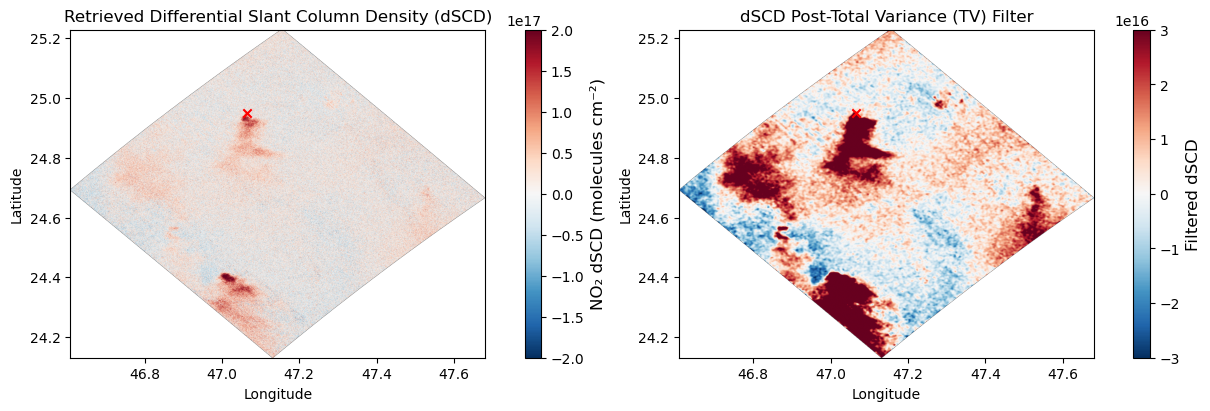

In [36]:
ds_no_orth = emit_xarray(radiance_fpath, ortho=False)
retrieval = np.load(retrieval_fpath)

dSCD = np.load(retrieval_fpath)
ds_no_orth = emit_xarray(radiance_fpath)

wl_val = float(ds_no_orth["wavelengths"].isel(wavelengths=0))  # or a specific value
dscd_da = xr.DataArray(
    dSCD.astype('float32')[..., None],  # -> (downtrack, crosstrack, 1)
    dims=("downtrack", "crosstrack", "wavelengths"),
    coords={
        "downtrack": ds_no_orth["downtrack"],
        "crosstrack": ds_no_orth["crosstrack"],
        "wavelengths": [wl_val],
    },
    name="dSCD",
    attrs={
        "long_name": "Differential Slant Column Density (single band)",
        "units": "molec cm^-2",
    },
)
ds_no_orth = ds_no_orth.assign(dSCD=dscd_da)
ds = ortho_xr(ds_no_orth)

(dy, dx) = ds.rio.resolution() # in deg
pix_pitch_m = 111000 * abs(dy)

del ds_no_orth

bounds = (np.min(ds['longitude'].values), np.max(ds['longitude'].values),
          np.min(ds['latitude'].values),  np.max(ds['latitude'].values))

# axs[i].imshow(ds['radiance'][:,:,0], cmap='gray', extent=bounds)
rad1500 = ds['radiance'].sel(wavelengths=1500, method='nearest').values
dSCD_nan = np.where(rad1500 <= -8000, np.nan, ds['dSCD'].values[:,:,0])*1e19

valid_lat = ds['latitude'].values[np.where(~np.isnan(dSCD_nan))[0]]
valid_lon = ds['longitude'].values[np.where(~np.isnan(dSCD_nan))[1]]

latmin_bnd, latmax_bnd = valid_lat.min(), valid_lat.max()
lonmin_bnd, lonmax_bnd = valid_lon.min(), valid_lon.max()

print(f"Completed orthorectification")

mask = np.isfinite(dSCD_nan)

_, idx = distance_transform_edt(~mask, return_indices=True)
filled = dSCD_nan[tuple(idx)]/1e19   # copies nearest valid value into each NaN pixel

tv = denoise_tv_chambolle(filled, weight=0.02)
tv[~mask] = np.nan


fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4), layout='constrained')

im = ax[0].imshow(dSCD_nan, cmap='RdBu_r', origin='upper', 
              aspect='auto', vmin=-2e17, vmax=2e17, extent=bounds)
cb = plt.colorbar(im, ax=ax[0])
cb.set_label("NO₂ dSCD (molecules cm⁻²)", fontsize=12)
ax[0].scatter([loc_data['LON']], [loc_data['LAT']], marker='x', c='red')
ax[0].set_title('Retrieved Differential Slant Column Density (dSCD)')

im = ax[1].imshow(tv*1e19, cmap='RdBu_r', origin='upper', 
              aspect='auto', vmin=-3e16, vmax=3e16, extent=bounds)
cb = plt.colorbar(im, ax=ax[1])
cb.set_label("Filtered dSCD", fontsize=12)
ax[1].scatter([loc_data['LON']], [loc_data['LAT']], marker='x', c='red')
ax[1].set_title('dSCD Post-Total Variance (TV) Filter')

for a in ax:
    a.set_xlim(lonmin_bnd, lonmax_bnd)
    a.set_ylim(latmin_bnd, latmax_bnd)

    a.set_ylabel('Latitude')
    a.set_xlabel('Longitude')

plt.show()

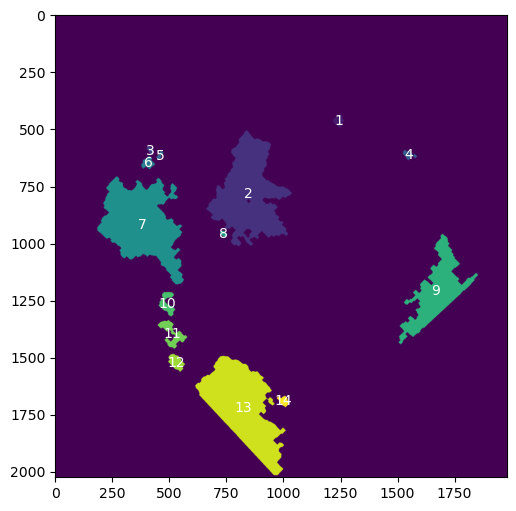

In [37]:
def get_plume_mask(img, pct=97, open_iters=4, close_iters=4, min_size=500):
    """
    img: 2D array (NaNs allowed)
    pct: percentile used for threshold (e.g., 95–99)
    open_iters/close_iters: morphology to denoise/bridge small gaps
    min_size: drop tiny specks before picking the two largest blobs
    """
    # 1) Threshold on high values (tune pct as needed)
    valid = np.isfinite(img)
    thr = np.nanpercentile(img, pct)
    bw = valid & (img >= thr)

    # 2) Morphology to clean the mask
    # Opening removes salt noise; closing bridges small gaps.
    bw = ndi.binary_opening(bw, iterations=open_iters)
    bw = ndi.binary_closing(bw, iterations=close_iters)

    # # Remove very small objects
    lbl, n = ndi.label(bw)
    # if n == 0:
    #     return np.zeros_like(bw, bool), np.zeros_like(bw, bool)

    sizes = ndi.sum(np.ones_like(bw), labels=lbl, index=np.arange(1, n+1))
    keep = {i+1 for i, s in enumerate(sizes) if s >= min_size}
    bw = np.isin(lbl, list(keep))

    # Re-label after size filter, fill holes
    lbl, n = ndi.label(bw)
    # if n == 0:
    #     return np.zeros_like(bw, bool), np.zeros_like(bw, bool)
    lbl = ndi.binary_fill_holes(lbl>0).astype(int) * lbl

    return lbl

lbls = get_plume_mask(tv, pct=80, open_iters=8, close_iters=8)
# lbls = get_plume_mask(dSCD_nan, pct=5, open_iters=18, close_iters=10)

plt.figure(figsize=(10,6))
plt.imshow(lbls, cmap='viridis')# extent=bounds)
# plt.scatter([loc_data['LON']], [loc_data['LAT']], marker='x', c='red')

# unique labels, excluding background (0)
regions = np.unique(lbls)
regions = regions[regions != 0]

for r in regions:
    cy, cx = center_of_mass(lbls == r)
    plt.text(cx, cy, str(r), color='white', fontsize=10, ha='center', va='center')

plt.show()

363573


Text(0, 0.5, 'Latitude')

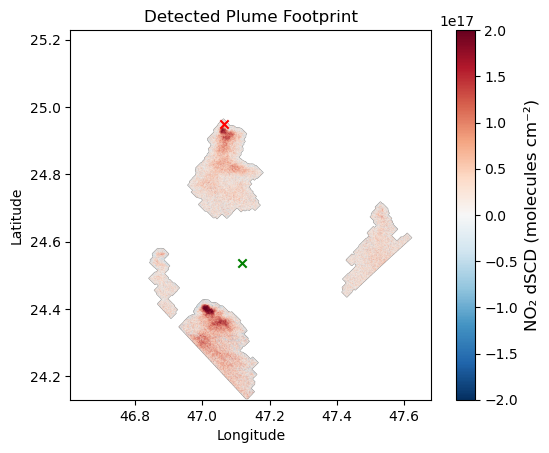

In [39]:
PLUME_ID = [2,8,10,11,12,13,9]

def get_mask(id_list, iter_dil=25, iter_ero=5):
    plume_mask = np.isin(lbls, id_list)
    
    plume_mask_filled = binary_fill_holes(plume_mask)
    plume_mask_filled = binary_dilation(plume_mask_filled, iterations=iter_dil)
    plume_mask_filled = binary_fill_holes(plume_mask_filled)
    plume_mask_filled = binary_erosion(plume_mask_filled, iterations=iter_ero)
    plume_mask_filled = binary_fill_holes(plume_mask_filled)
    # plume_mask_filled = binary_erosion(plume_mask_filled, iterations=iter_ero//4)
    # plume_mask_filled = binary_fill_holes(plume_mask_filled)
    # plume_mask_filled = binary_dilation(plume_mask_filled, iterations=iter_dil//4)
    # plume_mask_filled = binary_fill_holes(plume_mask_filled)

    return plume_mask_filled

pmask_1 = get_mask([2,8])
pmask_2 = get_mask([9])# | pmask_2 
pmask_3 = get_mask([10,11,12])
pmask_4 = get_mask([13]) #,iter_dil=30,iter_ero=10

plume_mask_filled = pmask_1 | pmask_2 | pmask_3 | pmask_4
# plume_mask_filled = get_mask(PLUME_ID, iter_dil=80,iter_ero=80)
plume_size_init = np.sum([1 if k else 0 for k in plume_mask_filled.flatten()])
print(plume_size_init)

## Get plume dSCD
dSCD_plume_masked = np.where(plume_mask_filled, dSCD_nan, np.nan)

## Get plume center
rows, cols = np.indices(dSCD_plume_masked.shape)
m = np.isfinite(dSCD_plume_masked)
xw = np.nansum(cols[m] * np.clip(dSCD_plume_masked[m], 0, None) ) / np.nansum(np.clip(dSCD_plume_masked[m], 0, None))
yw = np.nansum(rows[m] * np.clip(dSCD_plume_masked[m], 0, None) ) / np.nansum(np.clip(dSCD_plume_masked[m], 0, None))

## Boundary for full image, get a grid for lat/lon
bounds = (np.min(ds['longitude'].values), np.max(ds['longitude'].values),
          np.min(ds['latitude'].values),  np.max(ds['latitude'].values))

lon_grid = np.linspace(np.min(ds['longitude'].values), np.max(ds['longitude'].values), num=dSCD_plume_masked.shape[1])
lat_grid = np.linspace(np.min(ds['latitude'].values), np.max(ds['latitude'].values), num=dSCD_plume_masked.shape[0])

## Get bounding box
y_mask, x_mask = np.where(~np.isnan(dSCD_plume_masked))
pad = 50
# bbox = (max(0, x_mask.min()-pad), min(len(lon_grid)-1, x_mask.max()+pad),
#         max(-len(lat_grid)+1, -y_mask.min()+pad), min(0, -y_mask.max()-pad))

# bounding_box = (lon_grid[bbox[0]], lon_grid[bbox[1]], 
#                 lat_grid[bbox[2]], lat_grid[bbox[3]])


im = plt.imshow(dSCD_plume_masked, cmap='RdBu_r', extent=bounds, vmin=-2e17, vmax=2e17)
cb = plt.colorbar(im)
cb.set_label("NO₂ dSCD (molecules cm⁻²)", fontsize=12)
plt.scatter([lon_grid[int(xw)]], [lat_grid[-int(yw)]], marker='x', c='g')
plt.scatter([loc_data['LON']], [loc_data['LAT']], marker='x', c='red')

# lon_min, lon_max, lat_min, lat_max = bounding_box
# rect = patches.Rectangle((lon_min, lat_min), lon_max - lon_min, lat_max - lat_min,
#                  linewidth=2, edgecolor='k', facecolor='none')
# plt.gca().add_patch(rect)

plt.xlim(lonmin_bnd, lonmax_bnd)
plt.ylim(latmin_bnd, latmax_bnd)

plt.title("Detected Plume Footprint")
plt.xlabel('Longitude')
plt.ylabel('Latitude')

In [41]:
# np.save(f'PLOT_DATA/{loc_name}_{granule_name}_retrieval_mask_new.npy', ~np.isnan(dSCD_plume_masked[:,:]))

68627


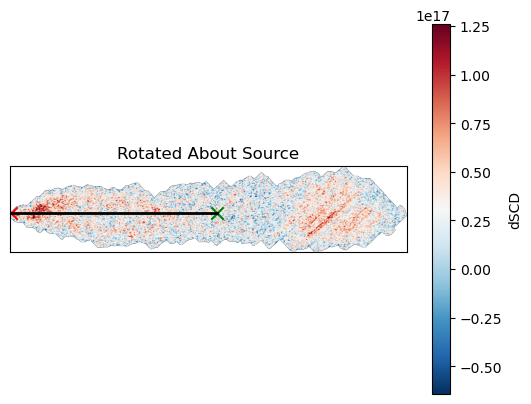

In [24]:
# --- helpers ---
ni = lambda v,a: int(np.argmin(np.abs(a - v)))

# pixel indices (global)
Rr,Rc = len(lat_grid)-ni(loc_data['LAT'], lat_grid), ni(loc_data['LON'], lon_grid) 
Gr, Gc = int(yw), int(xw)

# tight crop (with pad)
ym,xm = np.where(np.isfinite(dSCD_plume_masked)); pad=50
r0,r1 = max(0, ym.min()-pad), min(dSCD_plume_masked.shape[0], ym.max()+pad+1)
c0,c1 = max(0, xm.min()-pad), min(dSCD_plume_masked.shape[1], xm.max()+pad+1)
img   = dSCD_plume_masked[r0:r1, c0:c1].copy()
Rr,Rc,Gr,Gc = Rr-r0, Rc-c0, Gr-r0, Gc-c0

# plt.imshow(img); plt.scatter([Rc], [Rr]); plt.scatter([Gc], [Gr]); plt.show()

# angle to make red→green horizontal to the RIGHT
dx, dy = (Gc-Rc), (Gr-Rr)
angle  = -np.degrees(np.arctan2(-dy, dx))   # rotate by this

# pad so nothing clips; shift so RED at center
H,W = img.shape; P = max(H,W)
img  = np.pad(img, P, constant_values=np.nan)
Rr,Rc,Gr,Gc = Rr+P, Rc+P, Gr+P, Gc+P
H,W = img.shape; cy, cx = H/2, W/2

valid = np.isfinite(img).astype(float)

# plt.imshow(valid); plt.scatter([Rc], [Rr]); plt.scatter([Gc], [Gr]); plt.show()

vals  = np.nan_to_num(img, nan=0.0)
shift_vec = (cy - Rr, cx - Rc)
vals  = shift(vals,  shift_vec, order=1, mode='constant', cval=0.0, prefilter=False)
valid = shift(valid, shift_vec, order=1, mode='constant', cval=0.0, prefilter=False)

# plt.imshow(valid)
# print(vals.shape)
# print(valid.shape)

# normalized rotation (preserve plume; expand canvas)
num = rotate(vals*valid, angle, reshape=True, order=1, mode='constant', cval=0.0, prefilter=False)
den = rotate(valid,      angle, reshape=True, order=1, mode='constant', cval=0.0, prefilter=False)
with np.errstate(divide='ignore', invalid='ignore'):
    img_rot = num/den
img_rot[den < 1e-6] = np.nan

# plt.imshow(img_rot);
# print(np.isnan(img_rot))
plume_size_rot = np.sum([0 if k else 1 for k in np.isnan(img_rot.flatten())])
print(plume_size_rot)

# rotate GREEN relative to RED using the CORRECT image-space mapping
theta = np.deg2rad(-angle); c,s = np.cos(theta), np.sin(theta)
x_r =  c*dx - s*dy
y_r =  s*dx + c*dy

# red is now at canvas center; green goes to the right at same y
Rx, Ry = img_rot.shape[1]/2, img_rot.shape[0]/2
Gx, Gy = Rx + x_r, Ry + y_r   # Gy == Ry (horizontal), x_r > 0 (to the right)

# plot in pixel space (no lon/lat ticks)
plt.figure()
vmin, vmax = np.nanpercentile(img, [1,99]) if np.isfinite(img).any() else (None,None)
plt.imshow(img_rot, origin='upper', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(label='dSCD')
plt.plot([Rx, Gx], [Ry, Gy], 'k-', lw=2)        # horizontal by construction
plt.scatter([Rx],[Ry], c='r', marker='x', s=80) # source (center)
plt.scatter([Gx],[Gy], c='g', marker='x', s=80) # plume center (to the right)
ax=plt.gca()
# ax.set_xticks([]); ax.set_yticks([]); 
ax.set_aspect('equal','box')
plt.title('Rotated About Source')


vy = np.where(~np.isnan(img_rot))[0]
vx = np.where(~np.isnan(img_rot))[1]

plt.xlim(vx.min(), vx.max())
plt.ylim(vy.min(), vy.max())

plt.xticks([])
plt.yticks([])

plt.show()

In [25]:
Z_filled = img_rot
# import numpy as np
# from scipy import ndimage as ndi
# from scipy.spatial import cKDTree

# rotated_dscd = img_rot
# Z = rotated_dscd.copy()                 # 2D with NaNs
# valid = np.isfinite(Z)

# # 1) swath footprint = filled outline of where *any* data exists
# footprint = ndi.binary_fill_holes(valid)

# # 2) holes to fill = NaNs that are INSIDE the footprint
# holes = footprint & (~valid)

# # --- build KDTree on valid pixels INSIDE the footprint
# yy, xx = np.indices(Z.shape)
# pts_valid = np.c_[xx[valid], yy[valid]]
# vals_valid = Z[valid]
# tree = cKDTree(pts_valid)

# # 3) query neighbors for each hole pixel (local only)
# pts_hole = np.c_[xx[holes], yy[holes]]
# k = 12          # neighbors
# radius = 25.0   # max distance in pixels; tune 10–40

# d, idx = tree.query(pts_hole, k=k, distance_upper_bound=radius)

# # IDW weights (ignore neighbors beyond radius -> idx==len(vals_valid))
# good = np.isfinite(d) & (idx < len(vals_valid))
# w = np.zeros_like(d, dtype=float)
# w[good] = 1.0 / (d[good] + 1e-6)**2

# num = np.sum(w * vals_valid[np.clip(idx, 0, len(vals_valid)-1)], axis=1)
# den = np.sum(w, axis=1)

# fill_vals = np.full(len(pts_hole), np.nan, dtype=float)
# ok = den > 0
# fill_vals[ok] = num[ok] / den[ok]

# Z_filled = Z.copy()
# Z_filled[holes] = fill_vals

# # plot in pixel space (no lon/lat ticks)
# plt.figure()
# plt.imshow(Z_filled, origin='upper', cmap='RdBu_r', vmin=vmin, vmax=vmax)
# plt.colorbar(label='dSCD')
# plt.plot([Rx, Gx], [Ry, Gy], 'k-', lw=2)        # horizontal by construction
# plt.scatter([Rx],[Ry], c='r', marker='x', s=80) # source (center)
# plt.scatter([Gx],[Gy], c='g', marker='x', s=80) # plume center (to the right)
# ax=plt.gca()
# # ax.set_xticks([]); ax.set_yticks([]); 
# ax.set_aspect('equal','box')
# plt.title('Rotated About Source + Interpolated')

# vy = np.where(~np.isnan(Z_filled))[0]
# vx = np.where(~np.isnan(Z_filled))[1]

# plt.xlim(vx.min(), vx.max())
# plt.ylim(vy.min(), vy.max())

# plt.xticks([])
# plt.yticks([])

# plt.show()

In [26]:
l2a_fpath  = f"{CONFIG['data_folder']}/{loc_name}/EMIT_L2A_RFL_001_{granule_name}.nc"
L2A_xarr = emit_xarray(l2a_fpath, ortho=True)

emit_spec_wlen = L2A_xarr["wavelengths"].to_numpy().astype(np.float64)
window_sel = (emit_spec_wlen >= 405) & (emit_spec_wlen <= 465)
gler = L2A_xarr['reflectance'].sel(wavelengths=window_sel, method='nearest').values
gler = np.where(gler > -8000, gler, np.nan)
gler = np.nanmean(gler, axis=-1)
gler = np.nanmean(np.where(plume_mask_filled, gler, np.nan))

del L2A_xarr

obs_fpath  = f"{CONFIG['data_folder']}/{loc_name}/EMIT_L1B_OBS_001_{granule_name}.nc"
OBS_xarr = emit_xarray(obs_fpath, ortho=True)
obs_src = np.where(OBS_xarr['obs'] > -8000, OBS_xarr['obs'], np.nan)

sza = np.nanmean(np.where(plume_mask_filled, obs_src[:,:,4], np.nan))
vza = np.nanmean(np.where(plume_mask_filled, obs_src[:,:,2], np.nan))

to_sensor_az = np.array(obs_src[:,:,1])
to_sun_az = np.array(obs_src[:,:,3])
rel_azimuth = np.abs(to_sensor_az-to_sun_az)
rel_azimuth = np.minimum(rel_azimuth, 360.0 - rel_azimuth) # wrap to 0-180
phi = np.nanmean(np.where(plume_mask_filled, rel_azimuth, np.nan))

del OBS_xarr

print(f"{gler=} {sza=} {vza=} {phi=}")


# Convert altitude to pressure via barometric formula with H=8km
p0 = 1013
H = 8000
surface_altitude_m=1400
p = lambda z: p0 * np.exp(-z/H)
surface_pressure = p(surface_altitude_m)
pressure_at_500m = p(surface_altitude_m+500)
# print(f"Pressure at 500m above ground = {pressure_at_500m} hPa")

AMF_LUT = xr.load_dataset(CONFIG['AMF_LUT'])
amf_profile = AMF_LUT["damf"].interp(dspres=surface_pressure, 
                                     dpres=pressure_at_500m,
                                     dalb=gler, dphi=phi, 
                                     dvza=vza, dsza=sza).data

amf_eff = amf_profile+0 # for some reason this typecasts it properly

del AMF_LUT

amf_eff

gler=0.17984198 sza=24.414833 vza=6.307428 phi=45.037308


1.789037851090045

Approx pixel pitch: 60.88 m/pix
Plume-integrated NO₂ mass (kg·m^-2): 4.505e+03
L=42.49085992324579 pct=60
Mean retrieved emission rate: 0.42 kg/s


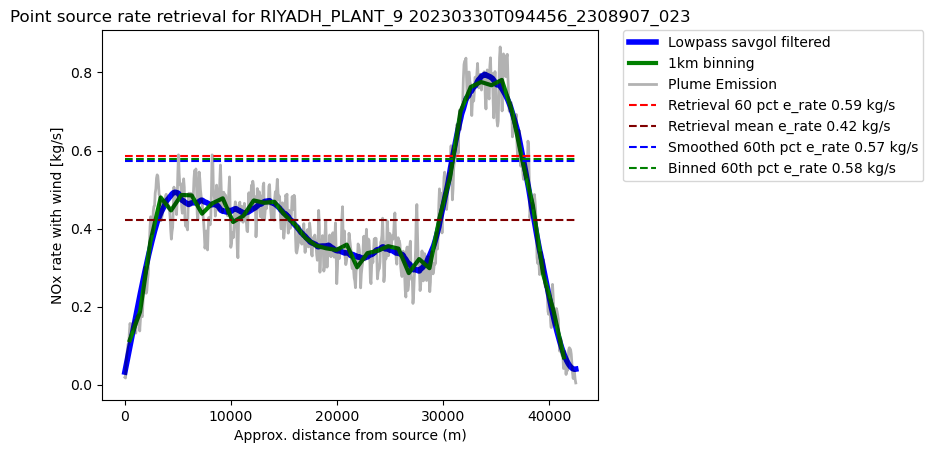

In [27]:
pix_pitch = pix_pitch_m * np.sqrt(plume_size_rot/plume_size_init)
print(f"Approx pixel pitch: {pix_pitch:0.4} m/pix")

AMF = amf_eff
integrated_flux = np.nansum(Z_filled, axis=0)*pix_pitch/AMF

# integrated_flux already defined
molec_to_kg_NO2 = 46 / (6.022e23 * 1000)
NOx_NO2_ratio = 1.4 # common value
NO2_kg_m2 = integrated_flux * molec_to_kg_NO2 * NOx_NO2_ratio * 1e4 # cm² → m²

# define indices
start_idx = int(Rx)  # source (red cross)
end_idx = np.where(NO2_kg_m2 > 0)[0][-1]

# threshold = 0.05 * np.nanmax(NO2_kg_m2)  # e.g. 5% of peak as cutoff
# end_idx = start_idx + np.argmax(NO2_kg_m2[start_idx:] < threshold)

# restrict the array
x = np.arange(len(NO2_kg_m2))
NO2_restricted = NO2_kg_m2[start_idx:end_idx]

# compute total plume mass (integrated along track)
plume_mass = np.nansum(NO2_restricted)*pix_pitch
print(f"Plume-integrated NO₂ mass (kg·m^-2): {plume_mass:.3e}")

plume_extent = x[start_idx:end_idx]*pix_pitch-start_idx*pix_pitch
plume_emission = NO2_kg_m2[start_idx:end_idx]

Z = [200, 250, 350, 450, 550, 650, 750]          # m
U = [wind_info["power_law"](z) for z in Z]  # or wind["log_law"](z)

Q = [plume_emission * float(u) for u in U]      # kg/s for each z
Q = np.mean(Q, axis=0); Q_unc = np.std(Q)

# Q = plume_emission*mean_windspeed
e_rate = np.mean(Q[Q > 0])


L = np.max(plume_extent)/1000

x_thresh = np.interp(L, [5, 25], [90, 60])
x_thresh = 10 * np.round(x_thresh / 10).astype(int)
pct = np.clip(x_thresh, 0, 90)

print(f"{L=} {pct=}")


print(f"Mean retrieved emission rate: {e_rate:0.2f} kg/s")

smoothed = savgol_filter(Q, window_length=101, polyorder=3) #smooth over 60*101 ~= 6km

# Smooth then base on top 10% of emission data
smoothed_maxrate = np.mean(smoothed[smoothed >= np.percentile(smoothed, pct)])

binned = np.array([np.mean(Q[x:x+16]) for x in range(0,len(Q)-16,16)])
bin_extent = [np.mean(plume_extent[x:x+16]) for x in range(0,len(Q)-16,16)]
bin_maxrate = np.mean(binned[binned >= np.percentile(binned, pct)])
plt.plot(bin_extent, binned)

nofilt_maxrate = np.mean(Q[Q >= np.percentile(Q, pct)])


plt.plot(plume_extent, smoothed,'blue', lw=4, label='Lowpass savgol filtered')
plt.plot(bin_extent, binned, 'green', lw=3, label='1km binning')
plt.plot(plume_extent, Q, 'k', lw=2, label='Plume Emission', alpha=0.3)


plt.hlines([nofilt_maxrate], xmin=0, xmax=np.max(plume_extent), color='red', linestyle='--', 
           label=f'Retrieval {pct} pct e_rate {nofilt_maxrate:0.2f} kg/s')
plt.hlines([e_rate], xmin=0, xmax=np.max(plume_extent), color='maroon', linestyle='--', 
           label=f'Retrieval mean e_rate {e_rate:0.2f} kg/s')
plt.hlines([smoothed_maxrate], xmin=0, xmax=np.max(plume_extent), color='blue', linestyle='--', 
           label=f'Smoothed {pct}th pct e_rate {smoothed_maxrate:0.2f} kg/s')
plt.hlines([bin_maxrate], xmin=0, xmax=np.max(plume_extent), color='green', linestyle='--', 
           label=f'Binned {pct}th pct e_rate {bin_maxrate:0.2f} kg/s')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plt.legend()
plt.title(f"Point source rate retrieval for {loc_name} {granule_name}")
plt.xlabel('Approx. distance from source (m)')
plt.ylabel('NOx rate with wind [kg/s]');

Text(0.5, 0.98, 'RIYADH_PLANT_9 20230330T094456_2308907_023')

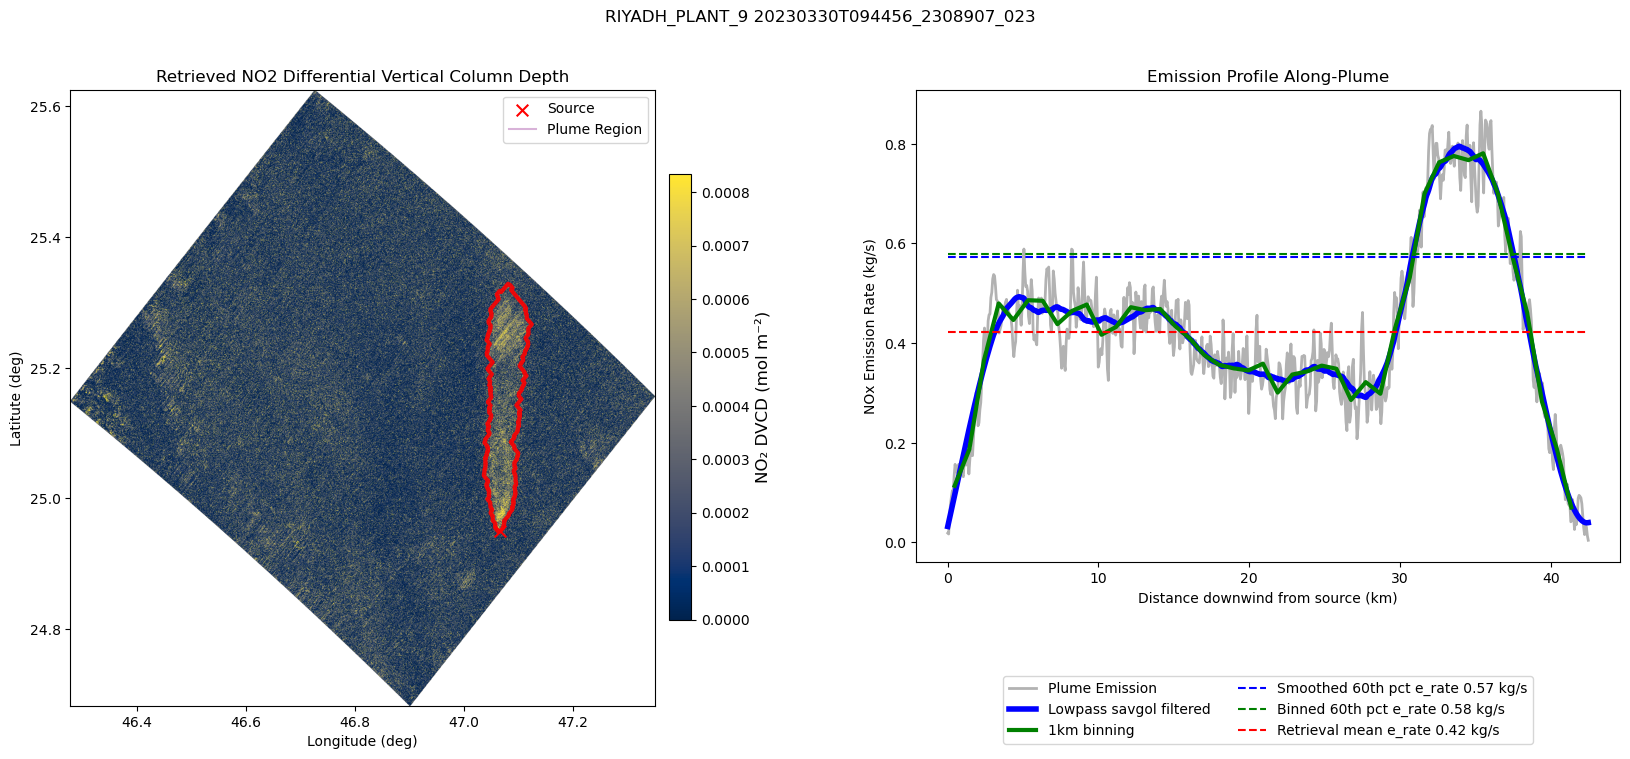

In [28]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20,8))

# plot_img = tv*1e19
plot_img = dSCD_nan
AVOG = 6.02214076e23
retr_vcd = (plot_img / amf_eff) * (1e4 / AVOG)   # molecules/cm^2 -> mol/m^2

im = ax[0].imshow(retr_vcd, cmap='cividis', 
                  vmin=0, vmax=np.nanpercentile(retr_vcd,98),
    extent=bounds, aspect="auto"
)

# im = ax[0].imshow(plot_img, cmap='seismic', origin='upper', 
#               aspect='auto', vmin=-2e17, vmax=2e17, extent=bounds)
# cb = fig.colorbar(im, ax=ax[0])

cb = fig.colorbar(im, ax=ax[0], shrink=0.85, pad=0.02)
cb.set_label("NO₂ DVCD (mol m⁻²)", fontsize=12)
# shrink height and move it down slightly
cb.ax.set_position([
    cb.ax.get_position().x0,          # same left
    cb.ax.get_position().y0 + 0.05,   # move down a bit
    cb.ax.get_position().width,       # same width
    cb.ax.get_position().height * 0.85  # shrink height (0.85 = 85%)
])
ax[0].scatter([loc_data['LON']], [loc_data['LAT']], marker='x', c='red', s=70, label='Source')
ax[0].contour(~np.isnan(dSCD_plume_masked[:,:]), levels=[0.5], 
            colors='red', alpha=0.9, linestyle='-', linewidths=3,
            extent=[bounds[0], bounds[1], bounds[3], bounds[2]])
np.save(f'PLOT_DATA/{loc_name}_{granule_name}_retrieval_mask_new.npy', ~np.isnan(dSCD_plume_masked[:,:]))

ax[0].plot([], color='purple', alpha=0.3, label='Plume Region')
ax[0].legend()
ax[0].set_title("Retrieved NO2 Differential Vertical Column Depth")
ax[0].set_xlabel("Longitude (deg)")
ax[0].set_ylabel("Latitute (deg)")

ax[0].set_xlim(lonmin_bnd, lonmax_bnd)
ax[0].set_ylim(latmin_bnd, latmax_bnd)

ax[1].plot(np.array(plume_extent)/1000, Q, 'k', lw=2, label='Plume Emission', alpha=0.3)
ax[1].plot(np.array(plume_extent)/1000, smoothed,'blue', lw=4, label='Lowpass savgol filtered')
ax[1].plot(np.array(bin_extent)/1000, binned, 'green', lw=3, label='1km binning')

ax[1].hlines([smoothed_maxrate], xmin=0, xmax=np.max(plume_extent)/1000, color='blue', linestyle='--', 
           label=f'Smoothed {pct}th pct e_rate {smoothed_maxrate:0.2f} kg/s')
ax[1].hlines([bin_maxrate], xmin=0, xmax=np.max(plume_extent)/1000, color='green', linestyle='--', 
           label=f'Binned {pct}th pct e_rate {bin_maxrate:0.2f} kg/s')
plt.hlines([e_rate], xmin=0, xmax=np.max(plume_extent)/1000, color='red', linestyle='--', 
           label=f'Retrieval mean e_rate {e_rate:0.2f} kg/s')
# ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


# shrink just this subplot height to make room
pos = ax[1].get_position()
ax[1].set_position([pos.x0, pos.y0 + 0.18, pos.width, pos.height - 0.18])

# legend under plot
ax[1].legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.40),
    ncol=2
)

ax[1].set_ylabel("NOx Emission Rate (kg/s)")
ax[1].set_xlabel("Distance downwind from source (km)")
ax[1].set_title("Emission Profile Along-Plume")

# y = np.array([0.74, 0.645, 0.12]).T
# x = np.array([0.59, 0.72, 0.11]).T

y = np.array([0.215, 0.245, 0.115,])#0.37])
x = np.array([0.18,  0.22,  0.14,])#  0.19])


# --- scatter ---
# ax[2].scatter(x, y, label="Retrievals")

# --- best fit line ---
coef = np.polyfit(x, y, 1)     # slope, intercept
m, b = coef
y_pred = m * x + b

# R^2
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res/ss_tot

# line for plotting
x_line = np.linspace(0, 0.4, 100)
y_line = m * x_line + b

label = f"y = {m:.3f}x + {b:.3f}\n$R^2$ = {r2:.3f}"
plt.suptitle(f"{loc_name} {granule_name}")
# plt.savefig(f"{loc_name}/{granule_name}_PLOT.png")

In [30]:
retrieval_log_fn = f'retr_{loc_name}.csv'
datalog_cols = ['GRANULE', 'SMOOTHED', 'BINNED', 'MEAN', 'AMF', 'PCT', 'L']

g_dat = {'GRANULE': granule_name,
        'SMOOTHED': smoothed_maxrate,
        'BINNED': bin_maxrate,
        'MEAN': e_rate,
        'AMF': amf_eff,
        'PCT': pct,
        'L': L}

if os.path.exists(retrieval_log_fn):
    retr_log = pd.read_csv(retrieval_log_fn) 
else:
    retr_log = pd.DataFrame(columns=datalog_cols)

if granule_name not in retr_log['GRANULE'].values:
    retr_log = pd.concat([retr_log, pd.DataFrame(g_dat, index=[0])])
else:
    retr_log.loc[retr_log['GRANULE'] == granule_name, datalog_cols[1:]] = [
        smoothed_maxrate, bin_maxrate, e_rate, amf_eff, pct, L
    ]
retr_log.to_csv(retrieval_log_fn, index=False)

In [ ]:
# -----------------------
# Inputs you already have
# -----------------------
nc_path = tropomi_save
qa_min = 0.75
src_lon, src_lat = loc_data["LON"], loc_data["LAT"]

# --- Open TROPOMI
tropomi_ds = xr.open_dataset(nc_path, engine="h5netcdf", group="PRODUCT")

no2 = tropomi_ds["nitrogendioxide_tropospheric_column"]
qa  = tropomi_ds["qa_value"]
lat = tropomi_ds["latitude"]
lon = tropomi_ds["longitude"]
trop_amf = tropomi_ds["air_mass_factor_troposphere"]

# drop singleton time dim if present
if "time" in no2.dims:  no2 = no2.isel(time=0)
if "time" in qa.dims:   qa  = qa.isel(time=0)
if "time" in lat.dims:  lat = lat.isel(time=0)
if "time" in lon.dims:  lon = lon.isel(time=0)
if "time" in trop_amf.dims:  trop_amf = trop_amf.isel(time=0)

# --- ROI mask (your plot bounds)
roi = (
    (lon >= lonmin_bnd) & (lon <= lonmax_bnd) &
    (lat >= latmin_bnd) & (lat <= latmax_bnd)
)

# --- Crop: keep only rows/cols that contain any ROI pixel
# (drop=True removes coordinates outside the mask’s extent)
no2 = no2.where(roi, drop=True)
qa  = qa.where(roi, drop=True)
lat = lat.where(roi, drop=True)
lon = lon.where(roi, drop=True)
trop_amf = trop_amf.where(roi, drop=True)

# optional: apply QA after cropping
no2m = no2.where(qa >= qa_min)
trop_amf = trop_amf.where(qa >= qa_min)
print(f"TROPOMI AMF: {np.nanmean(trop_amf)}")

C = np.asarray(no2m)     # mol/m^2
Y = np.asarray(lat)
X = np.asarray(lon)

deg2m = 111320.0

# gradient spacing in degrees
dlat = np.gradient(lat, axis=0)
dlon = np.gradient(lon, axis=1)

# convert to meters
dy_m = dlat * deg2m
dx_m = dlon * deg2m * np.cos(np.deg2rad(lat))

pixel_area = np.abs(dx_m * dy_m)  # m^2 per pixel

# --- Your retrieval: DSCD -> dVCD in mol/m^2 (as you were doing)
AVOG = 6.02214076e23
retr_vcd = (plot_img / amf_eff) * (1e4 / AVOG)   # molecules/cm^2 -> mol/m^2

# -----------------------
# Build a clean plume contour mask in lon/lat coordinates
# -----------------------
mask = np.isfinite(dSCD_plume_masked)
mask = ndi.binary_fill_holes(mask)
mask = ndi.binary_closing(mask, iterations=2)

lab, n = ndi.label(mask)
if n > 1:
    sizes = np.bincount(lab.ravel()); sizes[0] = 0
    mask = (lab == sizes.argmax())

xmin, xmax, ymin, ymax = bounds
# IMPORTANT: build YY increasing upward to match "extent=bounds" (ymin->ymax)
xs = np.linspace(xmin, xmax, mask.shape[1])
ys = np.linspace(ymax, ymin, mask.shape[0])
XX, YY = np.meshgrid(xs, ys)

# -----------------------
# Shared colormap + shared normalization
# -----------------------
cmap = "cividis"

# robust shared vmax: use combined 99th percentile inside the plume region if possible
# (falls back to max of each if region is tiny)
trop_vals = C[np.isfinite(C)]
retr_vals = retr_vcd[np.isfinite(retr_vcd)]
if trop_vals.size and retr_vals.size:
    vmax_shared = np.nanpercentile(np.r_[trop_vals, retr_vals], 99)
else:
    vmax_shared = np.nanmax([np.nanmax(C), np.nanmax(retr_vcd)])

# Optionally clamp to something sensible for paper figures:
# vmax_shared = min(vmax_shared, 1e-3)

norm = mpl.colors.Normalize(vmin=0.0, vmax=vmax_shared)

# -----------------------
# Plot
# -----------------------
fig, axs = plt.subplots(
    1, 2, figsize=(16, 6),
    constrained_layout=True,
    sharex=True, sharey=True
)

# Left: TROPOMI VCD
# m0 = axs[0].pcolormesh(X, Y, C, shading="auto", cmap=cmap, norm=norm)

no2m.plot.pcolormesh(
    ax=axs[0],
    x="longitude",
    y="latitude",
    shading="auto",
    cmap=cmap,
    norm=norm,
    add_colorbar=False
)
axs[0].scatter([src_lon], [src_lat], marker="x", c="red", s=70, linewidths=2, label="Source")
axs[0].contour(XX, YY, mask.astype(float), levels=[0.5], colors="red", alpha=0.7, linewidths=3)

axs[0].set_title(f"TROPOMI tropospheric NO₂ VCD (qa ≥ {qa_min})")
axs[0].set_xlabel("Longitude (deg)")
axs[0].set_ylabel("Latitude (deg)")

# Right: Retrieved ΔVCD
m1 = axs[1].imshow(
    retr_vcd, cmap=cmap, norm=norm,
    # origin="lower",  # because extent is in increasing y
    extent=bounds, aspect="auto"
)

# im = axs[1].imshow(plot_img/amf_eff * 1e4/AVOG, cmap='cividis', origin='upper', 
#               aspect='auto', vmin=0, vmax=1e-3, extent=bounds)

axs[1].scatter([src_lon], [src_lat], marker="x", c="red", s=70, linewidths=2, label="Source")
axs[1].contour(XX, YY, mask.astype(float), levels=[0.5], colors="red", alpha=0.7, linewidths=3)

axs[1].set_title("Retrieved NO₂ ΔVCD (background-subtracted)")
axs[1].set_xlabel("Longitude (deg)")

# Same map limits for both
for ax in axs:
    ax.set_xlim(lonmin_bnd, lonmax_bnd)
    ax.set_ylim(latmin_bnd, latmax_bnd)
    ax.grid(False)

# One legend (avoid duplicates)
handles, labels = axs[0].get_legend_handles_labels()
axs[0].legend(handles, labels, loc="upper right", frameon=True)
# optionally add a proxy for plume region in legend:
from matplotlib.lines import Line2D
plume_proxy = Line2D([0], [0], color="red", lw=3, alpha=0.7, label="Plume Region")
axs[0].legend(handles + [plume_proxy], labels + ["Plume Region"], loc="upper right", frameon=True)

loc_bounds = np.array([lonmin_bnd, lonmax_bnd, latmin_bnd, latmax_bnd])
np.save(f'PLOT_DATA/{loc_name}_{granule_name}_retrieval_mask_new.npy', mask.astype(float))
np.save(f"PLOT_DATA/{loc_name}_{granule_name}_retrieval_field_new.npy", retr_vcd)
np.save(f'PLOT_DATA/{loc_name}_{granule_name}_retrieval_bounds_new.npy', loc_bounds)
np.save(f'PLOT_DATA/{loc_name}_{granule_name}_retrieval_plot_bounds_new.npy', bounds)
np.save(f'PLOT_DATA/{loc_name}_{granule_name}_retrieval_mask.npy', mask)
np.save(f'PLOT_DATA/{loc_name}_{granule_name}_retrieval_loc.npy', loc_data)
# axs[1].scatter(47.20745083707684,24.954184708171166,  marker='x', color='cyan')
# Shared colorbar
cbar = fig.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=axs, fraction=0.035, pad=0.02
)
cbar.set_label("NO₂ vertical column density (mol m$^{-2}$)")

plt.show()
np.save(f"PLOT_DATA/{loc_name}_{granule_name}_retrieval_field.npy", retr_vcd)


In [37]:
retr_vcd_tv = (tv*1e19 / amf_eff) * (1e4 / AVOG)   # molecules/cm^2 -> mol/m^2
np.save(f'PLOT_DATA/{loc_name}_{granule_name}_retrieval_field_tv.npy', retr_vcd_tv)


In [38]:
import numpy as np

def upsample_conserve_density(M, r):
    """
    M: 2D array of mass-per-pixel (integrated)
    r: integer upscale factor
    returns: upsampled array with same total sum
    """
    M = np.asarray(M, float)
    return np.repeat(np.repeat(M, r, axis=0), r, axis=1)# / (r*r)

def subdivide_centers_to_fine_centers(latc, lonc, r):
    """
    Subdivide a coarse curvilinear grid (center coordinates) into an r x r per-cell fine grid.
    Inputs:
      latc, lonc : 2D arrays of shape (H, W) giving coarse cell center lat/lon (degrees)
      r          : integer upscale factor per axis (r >= 1)
    Returns:
      lat_fine, lon_fine : 2D arrays of shape (H*r, W*r) giving fine-grid subcell centers (degrees)
      valid_mask         : boolean array (H, W) True where the coarse cell had 4 finite corners
    Notes:
      - Uses bilinear interpolation between the four cell corners.
      - If a coarse cell has NaN corners it is marked invalid.
    """
    latc = np.asarray(latc, float)
    lonc = np.asarray(lonc, float)
    if latc.ndim != 2 or lonc.ndim != 2:
        raise ValueError("latc and lonc must be 2D arrays (H, W) of coarse centers")

    H, W = latc.shape
    if r == 1:
        return latc.copy(), lonc.copy(), np.ones((H, W), dtype=bool)

    # --- 1) compute corner grid (H+1, W+1) from centers
    # interior corners: average the 4 neighbouring centers (simple and stable)
    corners_lat = np.empty((H + 1, W + 1), dtype=float)
    corners_lon = np.empty((H + 1, W + 1), dtype=float)

    # fill interior corners as mean of four neighbouring centers
    corners_lat[1:-1, 1:-1] = 0.25 * (latc[:-1, :-1] + latc[1:, :-1] + latc[:-1, 1:] + latc[1:, 1:])
    corners_lon[1:-1, 1:-1] = 0.25 * (lonc[:-1, :-1] + lonc[1:, :-1] + lonc[:-1, 1:] + lonc[1:, 1:])

    # edges: average two centers (fallback)
    # top row corners (row 0) between center-row 0 and artificial extrapolation above:
    corners_lat[0, 1:-1] = 0.5 * (latc[0, :-1] + latc[0, 1:])
    corners_lon[0, 1:-1] = 0.5 * (lonc[0, :-1] + lonc[0, 1:])
    # bottom row
    corners_lat[-1, 1:-1] = 0.5 * (latc[-1, :-1] + latc[-1, 1:])
    corners_lon[-1, 1:-1] = 0.5 * (lonc[-1, :-1] + lonc[-1, 1:])
    # left column
    corners_lat[1:-1, 0] = 0.5 * (latc[:-1, 0] + latc[1:, 0])
    corners_lon[1:-1, 0] = 0.5 * (lonc[:-1, 0] + lonc[1:, 0])
    # right column
    corners_lat[1:-1, -1] = 0.5 * (latc[:-1, -1] + latc[1:, -1])
    corners_lon[1:-1, -1] = 0.5 * (lonc[:-1, -1] + lonc[1:, -1])

    # corners at the four extreme corners: just copy nearest center corner
    corners_lat[0, 0]   = latc[0, 0]
    corners_lat[0, -1]  = latc[0, -1]
    corners_lat[-1, 0]  = latc[-1, 0]
    corners_lat[-1, -1] = latc[-1, -1]
    corners_lon[0, 0]   = lonc[0, 0]
    corners_lon[0, -1]  = lonc[0, -1]
    corners_lon[-1, 0]  = lonc[-1, 0]
    corners_lon[-1, -1] = lonc[-1, -1]

    # --- 2) get four corner arrays per coarse cell
    TL_lat = corners_lat[0:H,   0:W  ]  # top-left
    TR_lat = corners_lat[0:H,   1:W+1]
    BL_lat = corners_lat[1:H+1, 0:W  ]
    BR_lat = corners_lat[1:H+1, 1:W+1]

    TL_lon = corners_lon[0:H,   0:W  ]
    TR_lon = corners_lon[0:H,   1:W+1]
    BL_lon = corners_lon[1:H+1, 0:W  ]
    BR_lon = corners_lon[1:H+1, 1:W+1]

    # valid mask for cells that have all finite corners
    valid_mask = np.isfinite(TL_lat) & np.isfinite(TR_lat) & np.isfinite(BL_lat) & np.isfinite(BR_lat) & \
                 np.isfinite(TL_lon) & np.isfinite(TR_lon) & np.isfinite(BL_lon) & np.isfinite(BR_lon)

    # --- 3) build subcell relative center coordinates (u, v) in (0,1)
    # u along x (columns), v along y (rows)
    # subcell centers positions within a coarse cell: (k+0.5)/r for k in 0..r-1
    u = (np.arange(r) + 0.5) / float(r)  # shape (r,)
    v = (np.arange(r) + 0.5) / float(r)  # shape (r,)

    uu = u[None, None, None, :]   # broadcast dims for (H, W, r, r)
    vv = v[None, None, :, None]   # note transpose placement so final axes match

    # We want an r x r block per coarse cell with (v along axis=2, u along axis=3)
    # compute bilinear interpolation weights for each corner:
    # lat_sub = (1-u)*(1-v)*TL + u*(1-v)*TR + (1-u)*v*BL + u*v*BR
    one_minus_u = 1.0 - uu
    one_minus_v = 1.0 - vv

    # Expand TL... to (H, W, r, r) for vectorized computation
    TL_lat_e = TL_lat[:, :, None, None]
    TR_lat_e = TR_lat[:, :, None, None]
    BL_lat_e = BL_lat[:, :, None, None]
    BR_lat_e = BR_lat[:, :, None, None]

    TL_lon_e = TL_lon[:, :, None, None]
    TR_lon_e = TR_lon[:, :, None, None]
    BL_lon_e = BL_lon[:, :, None, None]
    BR_lon_e = BR_lon[:, :, None, None]

    lat_sub = (one_minus_u * one_minus_v) * TL_lat_e \
            + (       uu * one_minus_v) * TR_lat_e \
            + (one_minus_u *       vv) * BL_lat_e \
            + (       uu *       vv) * BR_lat_e

    lon_sub = (one_minus_u * one_minus_v) * TL_lon_e \
            + (       uu * one_minus_v) * TR_lon_e \
            + (one_minus_u *       vv) * BL_lon_e \
            + (       uu *       vv) * BR_lon_e

    # lat_sub, lon_sub shape: (H, W, r, r)
    # reorder -> (H*r, W*r)
    lat_fine = np.transpose(lat_sub, (0, 2, 1, 3)).reshape(H * r, W * r)
    lon_fine = np.transpose(lon_sub, (0, 2, 1, 3)).reshape(H * r, W * r)

    return lat_fine, lon_fine, valid_mask

r = round(np.sqrt(np.nanmean(pixel_area))//pix_pitch_m)
no2_ups = upsample_conserve_density(no2m, r)
lat_ups, lon_ups, _ = subdivide_centers_to_fine_centers(no2m['latitude'], no2m['longitude'], r)

coords = {
    "latitude": (("y", "x"), lat_ups),
    "longitude": (("y", "x"), lon_ups),
}

no2m_ups = xr.DataArray(
    data=no2_ups.astype(no2m.dtype, copy=False),
    dims=("y", "x"),
    coords=coords,
    name=no2m.name,                 # keep same variable name
    attrs=no2m.attrs.copy(),         # keep units, etc.
)

approx_A = np.nanmean(pixel_area)
print(np.nansum(no2m*approx_A), np.nansum(no2_ups*approx_A/(117**2)))

763536.5 750540.3501080688


In [39]:
from scipy.spatial import cKDTree
# ----------------------------
# 0) Build retrieval lon/lat pixel centers for the MASK grid
# ----------------------------
xmin, xmax, ymin, ymax = bounds
Hr, Wr = mask.shape  # retrieval-grid mask shape

xs = np.linspace(xmin, xmax, Wr)
ys = np.linspace(ymax, ymin, Hr)  # origin='upper' convention (row 0 at ymax)
XR, YR = np.meshgrid(xs, ys)

# Flatten valid retrieval-mask pixels
rm = mask.astype(bool).ravel()
rlon = XR.ravel()[rm]
rlat = YR.ravel()[rm]

# ----------------------------
# 1) Assign those retrieval-mask pixels to nearest TROPOMI centers
# ----------------------------

C = np.asarray(no2m_ups)    # mol/m^2
Y = np.asarray(no2m_ups['latitude'])
X = np.asarray(no2m_ups['longitude'])

tlon = np.asarray(X).ravel()
tlat = np.asarray(Y).ravel()
t_ok = np.isfinite(tlon) & np.isfinite(tlat)

# KDTree in approx-meters by scaling lon by cos(lat0)
lat0 = np.nanmean(tlat[t_ok])
scale = np.cos(np.deg2rad(lat0))

tree = cKDTree(np.column_stack([tlat[t_ok], tlon[t_ok]*scale]))
dist, idx = tree.query(np.column_stack([rlat, rlon*scale]), k=1)

trop_flat_idx = np.flatnonzero(t_ok)[idx]

# Build a TROPOMI-grid plume mask from the mapped indices
plume_mask_trop = np.zeros(tlon.size, dtype=bool)
plume_mask_trop[trop_flat_idx] = True
plume_mask_trop = plume_mask_trop.reshape(C.shape)
plume_mask_trop = binary_fill_holes(plume_mask_trop)


ups_lat, ups_lon = no2m_ups['latitude'], no2m_ups['longitude']
in_bounds = (ups_lat >= latmin_bnd) & (ups_lat <= latmax_bnd) & (ups_lon >= lonmin_bnd) & (ups_lon <= lonmax_bnd)
bg_mask = in_bounds & ~plume_mask_trop.astype(bool)
background = np.nanmedian(no2m_ups.values[bg_mask])

print(background)

background = np.nanpercentile(no2m_ups.values[bg_mask], 10)

print(background)

no2m_bg_sub = no2m - background

# ----------------------------
# 2) Comparison domain on TROPOMI grid
# ----------------------------
valid = np.isfinite(C) & plume_mask_trop
x = C[valid].astype(float)

# ----------------------------
# 3) Metrics: Pearson r, RMA slope/intercept, integrated plume ratio
# ----------------------------

# Approx pixel area (m^2) from local lon/lat spacing (good for small crops)
deg2m = 111_320.0
dX = np.abs(np.gradient(X, axis=1))
dY = np.abs(np.gradient(Y, axis=0))
dx_m = np.nanmean(dX[valid]) * deg2m * np.cos(np.deg2rad(lat0))
dy_m = np.nanmean(dY[valid]) * deg2m
pix_area = dx_m * dy_m

M_trop = np.nansum(C[valid]-background) * (pix_area) * 0.0460055
M_retr = np.nansum(retr_vcd[mask])*(pix_pitch_m**2) * 0.0460055

plume_ratio = M_retr / M_trop if np.isfinite(M_trop) and M_trop != 0 else np.nan

# print(f"Pixels used (inside mapped plume):  {x.size}")
print(f"TROPOMI MASS:                      {M_trop: .3f} kg")
print(f"RETR MASS:                         {M_retr: .3f} kg")
print(f"Integrated plume ratio:            {plume_ratio: .3f}  (retr / trop)")

2.7422433e-05
1.7062317056115717e-05
TROPOMI MASS:                       5847.044 kg
RETR MASS:                          8408.161 kg
Integrated plume ratio:             1.438  (retr / trop)


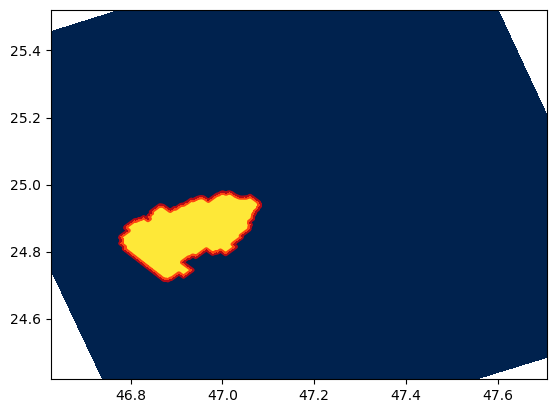

In [40]:
# plt.imshow()
plt.pcolormesh(X, Y, plume_mask_trop, shading="auto", cmap=cmap, norm=norm)
plt.contour(XX, YY, mask.astype(float), levels=[0.5],
               colors="red", alpha=0.7, linewidths=3)
for ax in [plt.gca()]:
    ax.set_xlim(lonmin_bnd, lonmax_bnd)
    ax.set_ylim(latmin_bnd, latmax_bnd)
    ax.grid(False)

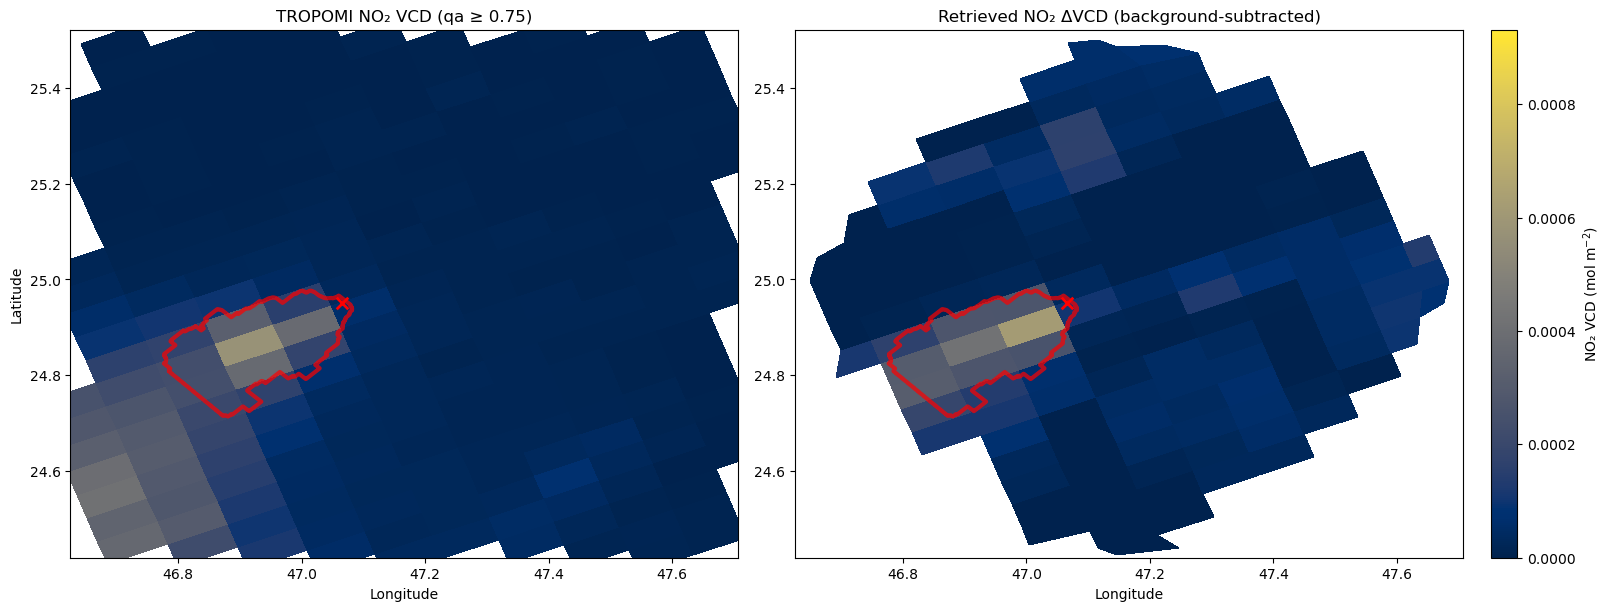

In [41]:
from scipy.spatial import cKDTree

C = np.asarray(no2m)     # mol/m^2
Y = np.asarray(lat)
X = np.asarray(lon)

# 1. Flatten TROPOMI grid
trop_lon_flat = X.ravel()
trop_lat_flat = Y.ravel()
valid_trop = np.isfinite(trop_lon_flat) & np.isfinite(trop_lat_flat)

cos_lat = np.cos(np.deg2rad(src_lat))
deg2m = 111320.0

trop_coords = np.column_stack([
    trop_lon_flat[valid_trop] * cos_lat * deg2m,
    trop_lat_flat[valid_trop] * deg2m
])
tree = cKDTree(trop_coords)

# 2. Flatten retrieval grid
xs_ret = np.linspace(bounds[0], bounds[1], retr_vcd.shape[1])
ys_ret = np.linspace(bounds[3], bounds[2], retr_vcd.shape[0])  # ymax->ymin (upper origin)
XX_ret, YY_ret = np.meshgrid(xs_ret, ys_ret)

ret_lon_flat = XX_ret.ravel()
ret_lat_flat = YY_ret.ravel()
ret_val_flat = retr_vcd.ravel()

valid_ret = np.isfinite(ret_val_flat)
ret_coords = np.column_stack([
    ret_lon_flat[valid_ret] * cos_lat * deg2m,
    ret_lat_flat[valid_ret] * deg2m
])
ret_vals = ret_val_flat[valid_ret]

# 3. Query with a max distance threshold (half a TROPOMI pixel, ~3.5 km)
dist, idx = tree.query(ret_coords, distance_upper_bound=5000)
in_range = np.isfinite(dist)  # cKDTree returns inf for no match

# 4. Bin: average retrieval values per TROPOMI pixel
n_trop = trop_coords.shape[0]
sums   = np.zeros(n_trop)
counts = np.zeros(n_trop)
np.add.at(sums,   idx[in_range], ret_vals[in_range])
np.add.at(counts, idx[in_range], 1)

mean_binned = np.full(n_trop, np.nan)
good = counts > 0
mean_binned[good] = sums[good] / counts[good]

# 5. Reshape to TROPOMI 2D grid
retr_on_trop = np.full(X.shape, np.nan)
retr_on_trop.ravel()[np.where(valid_trop)[0]] = mean_binned

# 6. Plot
fig, axs = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# Left: TROPOMI observed
no2m_bg_sub.plot.pcolormesh(
    ax=axs[0], x="longitude", y="latitude",
    shading="auto", cmap=cmap, norm=norm, add_colorbar=False
)
axs[0].scatter([src_lon], [src_lat], marker="x", c="red", s=70, linewidths=2)
axs[0].contour(XX, YY, mask.astype(float), levels=[0.5], colors="red", alpha=0.7, linewidths=3)
axs[0].set_title(f"TROPOMI NO₂ VCD (qa ≥ {qa_min})")

# Right: Retrieved VCD binned onto TROPOMI grid
# Fill NaN coordinates for pcolormesh
def nanfill_2d(arr):
    mask = np.isfinite(arr)
    if mask.all():
        return arr
    from scipy.interpolate import NearestNDInterpolator
    yy, xx = np.where(mask)
    interp = NearestNDInterpolator(list(zip(xx, yy)), arr[mask])
    yy_all, xx_all = np.where(~mask)
    arr[~mask] = interp(list(zip(xx_all, yy_all)))
    return arr

Xfill = nanfill_2d(X.astype(float).copy())
Yfill = nanfill_2d(Y.astype(float).copy())

axs[1].pcolormesh(
    Xfill, Yfill, retr_on_trop,
    shading="nearest", cmap=cmap, norm=norm
)
axs[1].scatter([src_lon], [src_lat], marker="x", c="red", s=70, linewidths=2)
axs[1].contour(XX, YY, mask.astype(float), levels=[0.5], colors="red", alpha=0.7, linewidths=3)
axs[1].set_title("Retrieved NO₂ ΔVCD (background-subtracted)")

for ax in axs:
    ax.set_xlim(lonmin_bnd, lonmax_bnd)
    ax.set_ylim(latmin_bnd, latmax_bnd)
    ax.set_xlabel("Longitude")
axs[0].set_ylabel("Latitude")

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axs, fraction=0.035, pad=0.02)
cbar.set_label("NO₂ VCD (mol m$^{-2}$)")
plt.show()

In [42]:
background

1.7062317056115717e-05

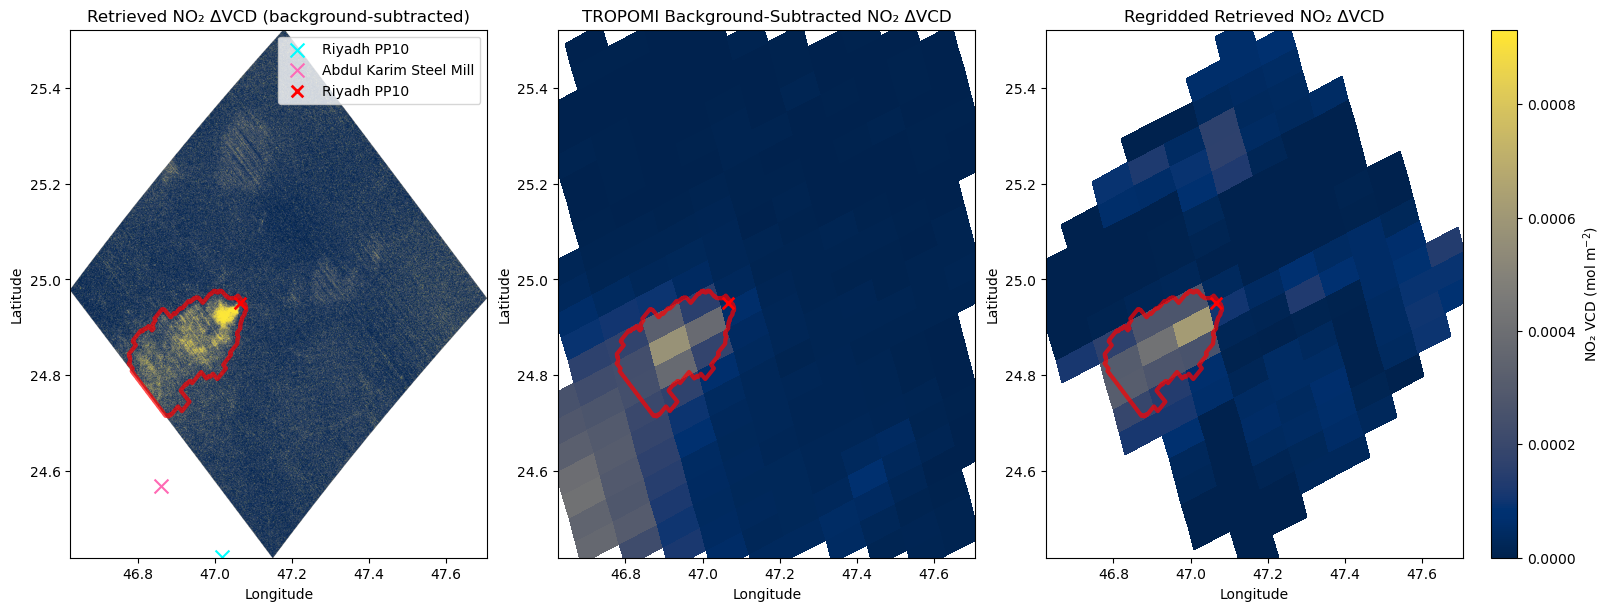

In [43]:
xmin, xmax, ymin, ymax = bounds
# IMPORTANT: build YY increasing upward to match "extent=bounds" (ymin->ymax)
xs = np.linspace(xmin, xmax, mask.shape[1])
ys = np.linspace(ymax, ymin, mask.shape[0])
XX, YY = np.meshgrid(xs, ys)

fig, axs = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True)

# Right: Retrieved ΔVCD
m1 = axs[0].imshow(
    retr_vcd, cmap=cmap, norm=norm,
    extent=bounds, aspect="auto"
)
axs[0].set_title("Retrieved NO₂ ΔVCD (background-subtracted)")

axs[0].scatter([47.01987304485973], [24.420909641204585], marker='x', s=100, color='cyan', label='Riyadh PP10')
# add_source_pt(R_loc_data['LAT'], R_loc_data['LON'], axs[1], color='red', label='Riyadh PP9')
# axs[0].scatter([47.530796721168585], [24.710624778668627],  marker='x', s=100, color='lime', label='Al Yamama Cement Factory')
axs[0].scatter([46.86114514726822],[24.568925126033204], marker='x', s=100, color='hotpink', label='Abdul Karim Steel Mill')


# Left: TROPOMI observed
xplotm, yplotm = no2m_bg_sub['longitude'], no2m_bg_sub['latitude']

axs[1].pcolormesh(
    xplotm, yplotm, no2m_bg_sub.values,
    shading="nearest", cmap=cmap, norm=norm
)
axs[1].set_title(f"TROPOMI Background-Subtracted NO₂ ΔVCD")


axs[2].pcolormesh(
    xplotm, yplotm, retr_on_trop,
    shading="nearest", cmap=cmap, norm=norm
)
axs[2].set_title("Regridded Retrieved NO₂ ΔVCD")

for ax in axs:
    ax.scatter([src_lon], [src_lat], marker="x", c="red", s=70, linewidths=2, label="Riyadh PP10")
    ax.contour(XX, YY, mask.astype(float), levels=[0.5], colors="red", alpha=0.7, linewidths=3)
    
    ax.set_xlim(lonmin_bnd, lonmax_bnd)
    ax.set_ylim(latmin_bnd, latmax_bnd)
    ax.set_xlabel("Longitude")
    ax.set_ylabel('Latitude')

axs[0].legend()

if True:
    np.save(f'PLOT_DATA/{loc_name}_{granule_name}_retrieval_mask.npy', mask.astype(float))
    np.save(f"PLOT_DATA/{loc_name}_{granule_name}_retrieval_field.npy", retr_vcd)
    np.save(f'PLOT_DATA/{loc_name}_{granule_name}_retrieval_bounds.npy', loc_bounds)
    np.save(f'PLOT_DATA/{loc_name}_{granule_name}_retrieval_plot_bounds.npy', bounds)
    np.save(f'PLOT_DATA/{loc_name}_{granule_name}_tropomi_dVCD.npy',no2m_bg_sub.values)
    np.save(f'PLOT_DATA/{loc_name}_{granule_name}_tropomi_grid.npy',np.array([xplotm.values,yplotm.values]))
    np.save(f'PLOT_DATA/{loc_name}_{granule_name}_retrieval_regridded.npy', retr_on_trop)
    np.save(f'PLOT_DATA/{loc_name}_{granule_name}_plume_mass.npy', np.array([M_retr, M_trop]))

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axs, fraction=0.035, pad=0.02)
cbar.set_label("NO₂ VCD (mol m$^{-2}$)")
plt.show()

In [44]:
granule_name

'20230824T083907_2323606_023'